# Fake News Detection Pipeline (v2)

This notebook demonstrates a streamlined pipeline for fake news detection:

1. **Data Processing**: Load raw data, clean source attribution, remove duplicates
2. **Train/Test Split**: Stratified split with configurable columns
3. **Feature Engineering**: TF-IDF vectorization
4. **Model Training**: Ridge Classifier and Logistic Regression
5. **Feature Importance**: Analyze what drives predictions

**Key improvement**: Feature and label columns are now explicitly configured and logged at each step.


In [1]:
import sys
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

# Add project root to path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import modules (with reload to pick up any changes)
from src.data import process_dataset, make_split
from src.features import make_features
from src.models import train_model as train_model_module

importlib.reload(make_features)
importlib.reload(train_model_module)

run_feature_engineering = make_features.run_feature_engineering
train_model = train_model_module.train_model
load_config = train_model_module.load_config

print("✓ Imports successful")


✓ Imports successful


In [2]:
# Load configuration and define paths
config = load_config(str(project_root / "config" / "config.yaml"))

# Get column configuration
FEATURE_COLUMN = config["columns"]["feature_column"]
LABEL_COLUMN = config["columns"]["label_column"]
ID_COLUMN = config["columns"]["id_column"]

print("Configuration loaded:")
print(f"  Feature column (X): '{FEATURE_COLUMN}'")
print(f"  Label column (y):   '{LABEL_COLUMN}'")
print(f"  ID column:          '{ID_COLUMN}'")


Configuration loaded:
  Feature column (X): 'text'
  Label column (y):   'label'
  ID column:          'id'


## 1. Data Processing

Load raw data, clean source attribution (e.g., "(Reuters) -"), and remove duplicates.


In [3]:
# Define paths
raw_data_path = project_root / "data" / "raw" / "WELFake_Dataset.csv"
cleaned_data_path = project_root / "data" / "processed" / "cleaned_dataset.csv"

# Process dataset: load, clean source attribution, deduplicate
df = process_dataset(
    input_path=str(raw_data_path),
    output_path=str(cleaned_data_path),
    feature_column=FEATURE_COLUMN,
    label_column=LABEL_COLUMN,
    id_column=ID_COLUMN
)


DATA PROCESSING
Input:  /Users/alanye/Fake-News-Group-3/data/raw/WELFake_Dataset.csv
Output: /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv

1. Loading dataset...
   Loaded 72,134 rows
   Columns: ['id', 'title', 'text', 'label']

2. Cleaning source attribution from 'text' column...
   Removing patterns like '(Reuters) -', '(AP) -', etc.
   ✓ Source attribution removed

3. Removing duplicate articles (based on 'text')...
   Removed 9,415 duplicates
   Remaining: 62,719 unique articles

4. Label distribution ('label' column):
   0 (Real): 34,620 (55.2%)
   1 (Fake): 28,099 (44.8%)

5. Saving cleaned data...
✓ Saved 62719 rows to /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv

✓ DATA PROCESSING COMPLETE
  Feature column: 'text'
  Label column:   'label'
  Total rows:     62,719
  Saved to:       /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv


## 2. Train/Test Split

Create stratified train/test split (80/20) based on label column.


In [4]:
processed_dir = project_root / "data" / "processed"

train_df, test_df = make_split(
    input_path=str(cleaned_data_path),
    output_dir=str(processed_dir),
    test_size=config["models"]["test_size"],
    random_seed=config["models"]["random_seed"],
    label_column=LABEL_COLUMN,
    feature_column=FEATURE_COLUMN
)


TRAIN/TEST SPLIT

1. Loading data from /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv...
   Loaded 62,719 rows

2. Validating columns...
   Feature column (X): 'text'
   Label column (y):   'label'
   ✓ All required columns present

3. Label distribution (before split):
   0 (Real): 34,620 (55.2%)
   1 (Fake): 28,099 (44.8%)

4. Splitting data (test_size=0.2, random_seed=42)...

5. Saving splits...
   Train: /Users/alanye/Fake-News-Group-3/data/processed/train.csv (50,175 rows)
   Test:  /Users/alanye/Fake-News-Group-3/data/processed/test.csv (12,544 rows)

✓ SPLIT COMPLETE
  Feature column: 'text'
  Label column:   'label'
  Train samples:  50,175
  Test samples:   12,544


In [12]:
test_df

,id,title,text,label
55630,62942,Newt Gingrich Defends Donald Trump Against 'Se...,\nDonald Trump supporter and former Speaker o...,1
60876,69764,U.S. lawmakers reach deal for Senate Russia sa...,WASHINGTON/MOSCOW/BRUSSELS (Reuters) - U.S. la...,0
19291,20260,KKK Just Threatened An 84-Year-Old Woman Who ...,An elderly Massachussetts woman who wrote a le...,1
8621,8886,Uber Releases Diversity Report and Repudiates ...,SAN FRANCISCO — After a string of scandals ...,0
20198,21240,WATCH: Republican Heartlessly Tells A Mother ...,Wow. The cruelty of Republicans knows no bound...,1
...,...,...,...,...
51563,57770,"Trump to scrap protection for 'Dreamers,' give...",President Donald Trump has decided to scrap a ...,0
39286,42921,Norway government to rule in minority after ce...,Norway s Christian Democratic party withdrew f...,0
3904,3982,It’s Children Against Federal Lawyers in Immig...,"TUCSON — After a long, scary trek through t...",0
39658,43371,Report: US Investigators Had Concern That Brad...,"Apparently, Tom Brady’s missing Super Bowl jer...",0


In [13]:
train_df

,id,title,text,label
20854,21964,Watchdog Claims 5K Noncitizens Registered to V...,A new report released shortly after the formin...,0
31798,34239,France to discuss possible new Rafale sale wit...,France will discuss the possible sale of more ...,0
8516,8776,WATCH: GOP Governor Tells Christians To Marty...,This is why we have separation of church and s...,1
30199,32414,Philippines to ask China to clarify its intent...,"Philippine President Rodrigo Duterte, in an ap...",0
18254,19127,The BBC Asks – What Really Happened With the C...,at 11:54 am 4 Comments \nWhen it comes to the ...,1
...,...,...,...,...
383,386,Comment on World Heaves Sigh of Relief after T...,Finian Cunningham has written extensively on...,1
28755,30795,ALARMING! THIS STATE’S SCHOOL SYSTEM TO TAKE O...,The ultimate nanny state move in this liberal ...,1
41849,45964,Merkel optimistic EU dispute over refugee dist...,German Chancellor Angela Merkel said she was o...,0
40422,44271,Global Warming Scammer Makes Millions BUT Is J...,Global warming has been shoved down the throat...,1


## 3. Feature Engineering

Convert text to TF-IDF vectors (unigrams + bigrams, max 5000 features).


In [5]:
run_feature_engineering(
    processed_dir=str(processed_dir),
    feature_column=FEATURE_COLUMN,
    label_column=LABEL_COLUMN,
    max_features=config["features"]["tfidf"]["max_features"]
)


FEATURE ENGINEERING

1. Loading train/test split...

2. Extracting features and labels...
   Feature column (X): 'text'
   Label column (y):   'label'

   Train samples: 50,175
   Test samples:  12,544

   Label distribution (train):
     0 (Real): 27,696 (55.2%)
     1 (Fake): 22,479 (44.8%)

3. Creating TF-IDF features...
   Max features: 5,000
   N-gram range: (1, 2)
   ✓ Train TF-IDF shape: (50175, 5000)
   ✓ Test TF-IDF shape:  (12544, 5000)

4. Creating Word2Vec/Sentence2Vec features...
   Training Word2Vec model...
   Generating sentence vectors...
   ✓ Train W2V shape: (50175, 100)
   ✓ Test W2V shape:  (12544, 100)

5. Saving features to /Users/alanye/Fake-News-Group-3/data/processed...
   ✓ TF-IDF features saved
   ✓ Word2Vec features saved

✓ FEATURE ENGINEERING COMPLETE
  Feature column: 'text'
  Label column:   'label'
  TF-IDF shape:   (50175, 5000)
  Word2Vec shape: (50175, 100)


## 4. Model Training

Train Ridge Classifier and Logistic Regression models.


In [6]:
# Train Ridge Classifier
ridge_model, ridge_metrics, ridge_preds = train_model(
    "ridge_classifier", config, return_metrics=True,
    processed_dir=str(processed_dir),
    models_dir=str(project_root / "results" / "models")
)


MODEL TRAINING: ridge_classifier

1. Loading features and labels...
   Loading: /Users/alanye/Fake-News-Group-3/data/processed/features_train_tfidf.npz
   Loading: /Users/alanye/Fake-News-Group-3/data/processed/features_test_tfidf.npz

2. Data summary:
   Feature source: 'text' column → TF-IDF vectors
   Label source:   'label' column (0=Real, 1=Fake)

   X_train shape: (50175, 5000)
   X_test shape:  (12544, 5000)

   Label distribution:
     Train: 0=27696, 1=22479
     Test: 0=6924, 1=5620

3. Initializing ridge_classifier...
   Using default parameters

4. Training model...
   ✓ Training complete

5. Evaluating on test set...

   Accuracy: 0.9373

   Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.94      0.95      0.94      6924
    Fake (1)       0.94      0.92      0.93      5620

    accuracy                           0.94     12544
   macro avg       0.94      0.94      0.94     12544
weighted avg       0.94      0.94      0.9

In [7]:
# Train Logistic Regression
lr_model, lr_metrics, lr_preds = train_model(
    "logistic_regression", config, return_metrics=True,
    processed_dir=str(processed_dir),
    models_dir=str(project_root / "results" / "models")
)


MODEL TRAINING: logistic_regression

1. Loading features and labels...
   Loading: /Users/alanye/Fake-News-Group-3/data/processed/features_train_tfidf.npz
   Loading: /Users/alanye/Fake-News-Group-3/data/processed/features_test_tfidf.npz

2. Data summary:
   Feature source: 'text' column → TF-IDF vectors
   Label source:   'label' column (0=Real, 1=Fake)

   X_train shape: (50175, 5000)
   X_test shape:  (12544, 5000)

   Label distribution:
     Train: 0=27696, 1=22479
     Test: 0=6924, 1=5620

3. Initializing logistic_regression...
   Parameters: {'C': 1.0, 'max_iter': 1000, 'solver': 'lbfgs'}

4. Training model...
   ✓ Training complete

5. Evaluating on test set...

   Accuracy: 0.9338

   Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.93      0.95      0.94      6924
    Fake (1)       0.93      0.92      0.93      5620

    accuracy                           0.93     12544
   macro avg       0.93      0.93      0.93     12544
w

In [15]:
import numpy as np
import pandas as pd
import joblib

# Load the training features
train_data = np.load("../data/processed/features_train_tfidf.npz", allow_pickle=True)
X_train = train_data["X"].item()  # Extract sparse matrix
y_train = train_data["y"]

print("X_train (Features):")
print(f"  Shape: {X_train.shape}")
print(f"  Type: {type(X_train)}")

print("\ny_train (Labels):")
print(f"  Shape: {y_train.shape}")
print(f"  Values: {np.unique(y_train, return_counts=True)}")

# Show sample
vectorizer = joblib.load("../data/processed/tfidf_vectorizer.pkl")
feature_names = vectorizer.get_feature_names_out()

sample_row = X_train[0].toarray().flatten()
nonzero = np.where(sample_row > 0)[0]
print(f"\nSample row 0 (label={y_train[0]}):")
print(f"  Non-zero features: {len(nonzero)}")
print(f"  Top features: {[(feature_names[i], f'{sample_row[i]:.3f}') for i in nonzero[np.argsort(sample_row[nonzero])[-5:]]]}")

X_train (Features):
  Shape: (50175, 5000)
  Type: <class 'scipy.sparse._csr.csr_matrix'>

y_train (Labels):
  Shape: (50175,)
  Values: (array([0, 1]), array([27696, 22479]))

Sample row 0 (label=0):
  Non-zero features: 187
  Top features: [('foundation', '0.173'), ('registration', '0.179'), ('report', '0.194'), ('alien', '0.242'), ('virginia', '0.361')]


In [16]:
import numpy as np
import pandas as pd
import joblib

# Load the training features
train_data = np.load(str(processed_dir / "features_train_tfidf.npz"), allow_pickle=True)
X_train = train_data["X"].item()  # Extract sparse matrix
y_train = train_data["y"]

# Load vectorizer to get feature names
vectorizer = joblib.load(str(processed_dir / "tfidf_vectorizer.pkl"))
feature_names = vectorizer.get_feature_names_out()

# Convert sparse matrix to DataFrame (first 100 rows to avoid memory issues)
n_samples = 100
X_sample = X_train[:n_samples].toarray()

df_features = pd.DataFrame(X_sample, columns=feature_names)
df_features.insert(0, 'label', y_train[:n_samples])

print(f"Shape: {df_features.shape}")
print(f"Columns: label + {len(feature_names)} TF-IDF features")
print(f"\nFirst 5 rows, first 10 columns:")
display(df_features.iloc[:5, :10])

# Show non-zero features for first sample
print(f"\nSample 0 (label={y_train[0]}) - Non-zero features:")
row = df_features.iloc[0, 1:]  # Exclude label column
nonzero = row[row > 0].sort_values(ascending=False)
print(nonzero.head(20))

Shape: (100, 5001)
Columns: label + 5000 TF-IDF features

First 5 rows, first 10 columns:


,label,00,000,000 people,10,10 000,10 percent,10 years,100,100 000
0,0,0.0,0.028425,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000
1,0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000
2,1,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000
3,0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000
4,1,0.0,0.099755,0.033339,0.042728,0.0,0.0,0.0,0.051506,0.074784



Sample 0 (label=0) - Non-zero features:
virginia        0.361078
alien           0.241893
report          0.194245
registration    0.178595
foundation      0.173011
officials       0.169605
information     0.165628
registered      0.153575
effort          0.142848
legal           0.141155
voter           0.139677
study           0.133074
total           0.120083
illegal         0.114731
citizens        0.114062
deportation     0.113623
public          0.106251
local           0.104474
integrity       0.104241
voters          0.101924
Name: 0, dtype: float64


### Model Comparison


MODEL COMPARISON

Features used: 'text' column → TF-IDF
Labels used:   'label' column (0=Real, 1=Fake)

Ridge Classifier Accuracy:    0.9373
Logistic Regression Accuracy: 0.9338


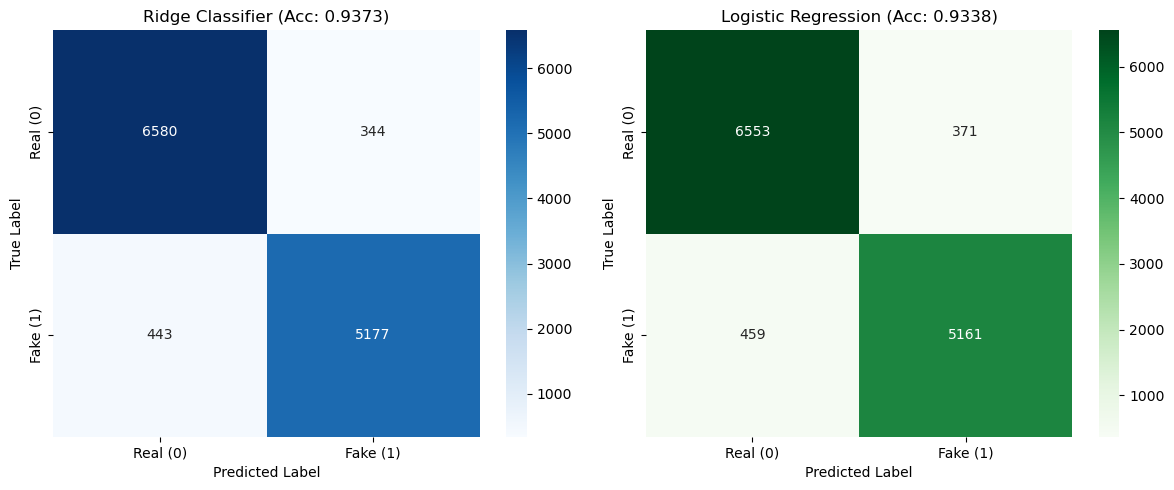

In [8]:
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"\nFeatures used: '{ridge_metrics['feature_column']}' column → TF-IDF")
print(f"Labels used:   '{ridge_metrics['label_column']}' column (0=Real, 1=Fake)")
print(f"\nRidge Classifier Accuracy:    {ridge_metrics['accuracy']:.4f}")
print(f"Logistic Regression Accuracy: {lr_metrics['accuracy']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ridge Confusion Matrix
sns.heatmap(ridge_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
axes[0].set_title(f"Ridge Classifier (Acc: {ridge_metrics['accuracy']:.4f})")
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Logistic Regression Confusion Matrix
sns.heatmap(lr_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
axes[1].set_title(f"Logistic Regression (Acc: {lr_metrics['accuracy']:.4f})")
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


## 5. Feature Importance Analysis

Analyze which words/n-grams are most predictive of fake vs real news.


In [9]:
import joblib

# Load the TF-IDF vectorizer to get feature names
vectorizer = joblib.load(str(processed_dir / "tfidf_vectorizer.pkl"))
feature_names = vectorizer.get_feature_names_out()

def get_top_features(model, feature_names, n=20):
    """Extract top positive and negative features from a linear model."""
    coefs = model.coef_[0] if model.coef_.ndim > 1 else model.coef_
    
    df_features = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefs
    })
    
    # Positive coefficients → predict Fake (1)
    top_fake = df_features.nlargest(n, 'coefficient')[['feature', 'coefficient']]
    
    # Negative coefficients → predict Real (0)
    top_real = df_features.nsmallest(n, 'coefficient')[['feature', 'coefficient']]
    
    return top_fake, top_real

ridge_fake, ridge_real = get_top_features(ridge_model, feature_names)
lr_fake, lr_real = get_top_features(lr_model, feature_names)


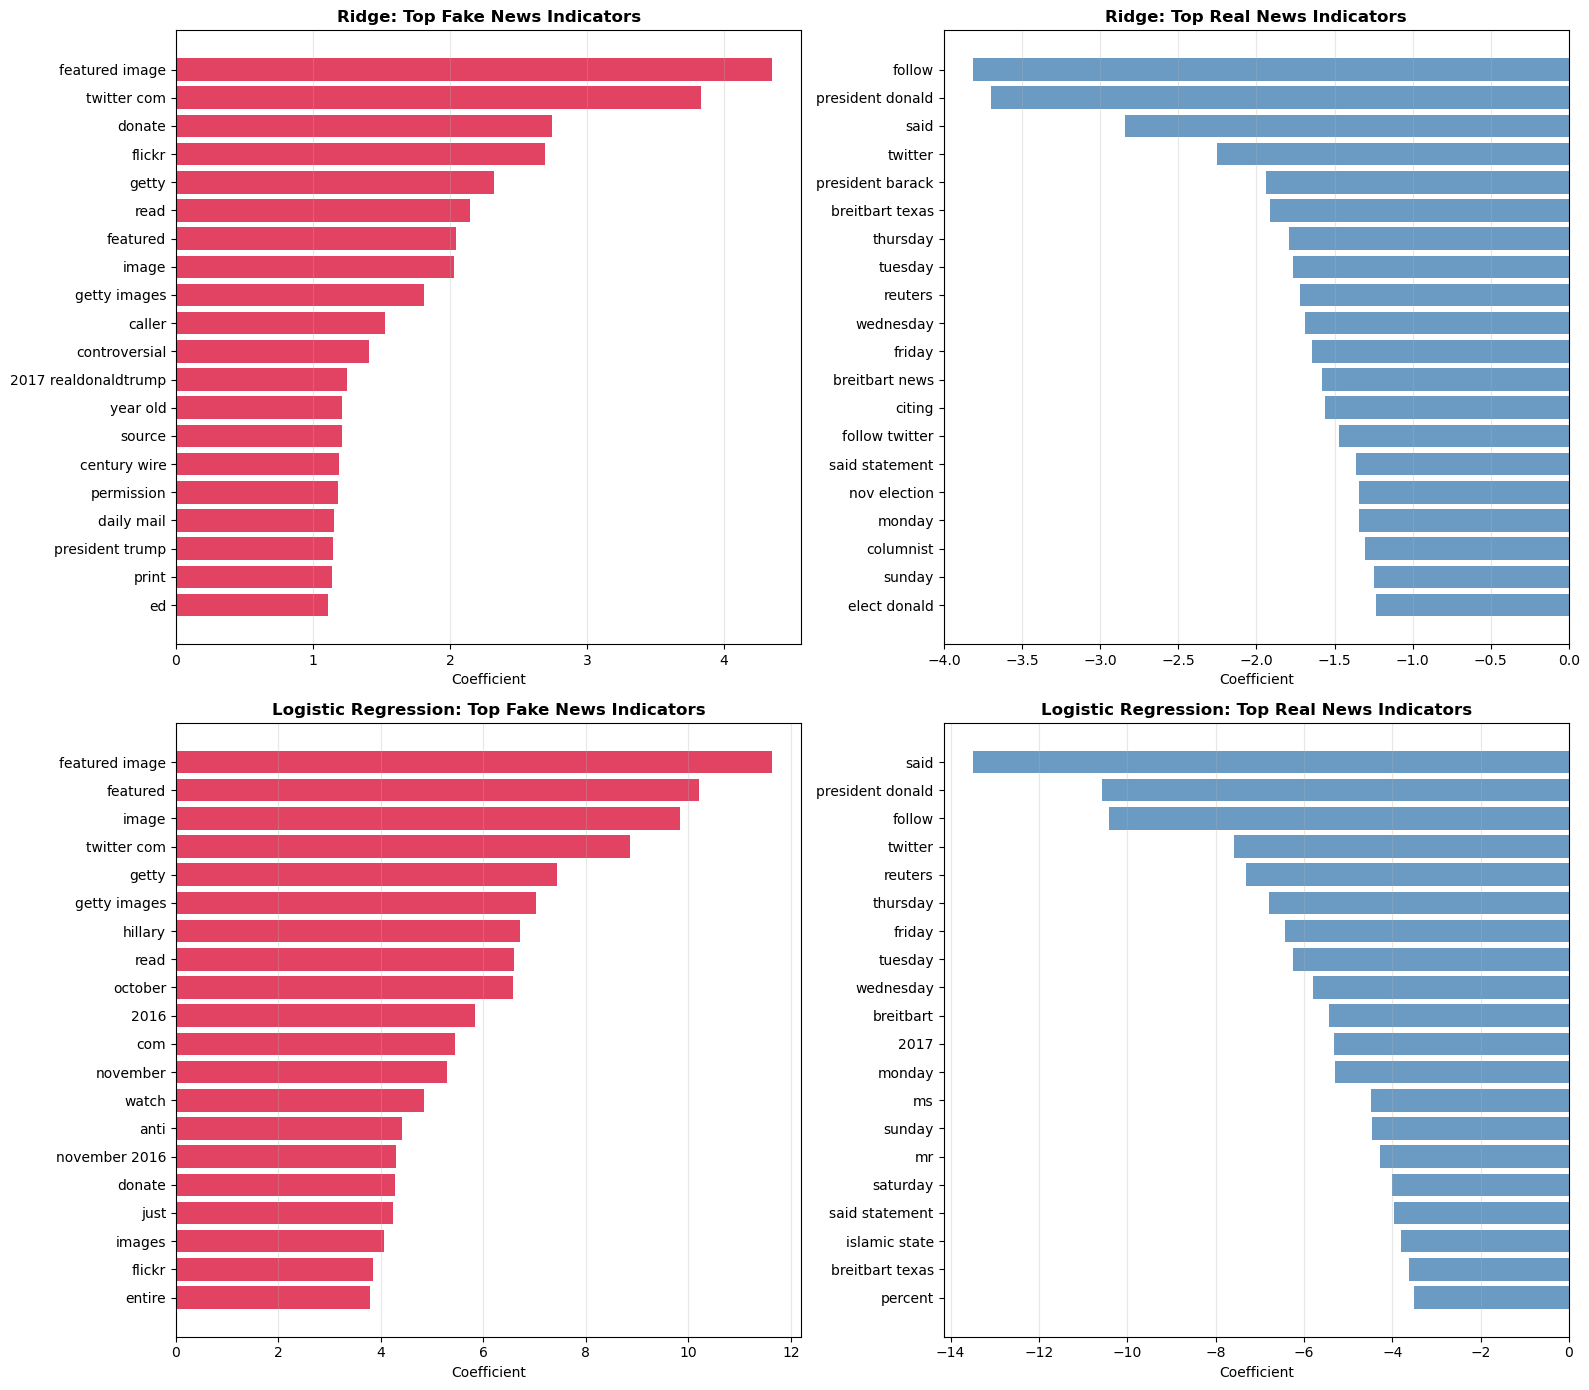

In [10]:
# Visual comparison of feature importance
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, data, title, color in [
    (axes[0, 0], ridge_fake, 'Ridge: Top Fake News Indicators', 'crimson'),
    (axes[0, 1], ridge_real, 'Ridge: Top Real News Indicators', 'steelblue'),
    (axes[1, 0], lr_fake, 'Logistic Regression: Top Fake News Indicators', 'crimson'),
    (axes[1, 1], lr_real, 'Logistic Regression: Top Real News Indicators', 'steelblue'),
]:
    y_pos = np.arange(len(data))
    ax.barh(y_pos, data['coefficient'].values, color=color, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(data['feature'].values)
    ax.invert_yaxis()
    ax.set_xlabel('Coefficient')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
# Feature overlap between models
ridge_fake_set = set(ridge_fake['feature'].values)
ridge_real_set = set(ridge_real['feature'].values)
lr_fake_set = set(lr_fake['feature'].values)
lr_real_set = set(lr_real['feature'].values)

fake_overlap = ridge_fake_set & lr_fake_set
real_overlap = ridge_real_set & lr_real_set

print("=" * 60)
print("FEATURE OVERLAP BETWEEN MODELS")
print("=" * 60)
print(f"\nFake News Indicators (both models agree): {len(fake_overlap)}/20")
print(sorted(fake_overlap))
print(f"\nReal News Indicators (both models agree): {len(real_overlap)}/20")
print(sorted(real_overlap))


FEATURE OVERLAP BETWEEN MODELS

Fake News Indicators (both models agree): 9/20
['donate', 'featured', 'featured image', 'flickr', 'getty', 'getty images', 'image', 'read', 'twitter com']

Real News Indicators (both models agree): 13/20
['breitbart texas', 'follow', 'friday', 'monday', 'president donald', 'reuters', 'said', 'said statement', 'sunday', 'thursday', 'tuesday', 'twitter', 'wednesday']
